In [34]:
import torch
import torch.nn as nn
import pickle
import numpy as np
import torchvision
import matplotlib.pyplot as plt
from torch.utils.flop_counter import FlopCounterMode
from typing import Union, Tuple
import os
from mpl_toolkits import axes_grid1
import re
from models import get_model_for_dataset
from models.utils import is_cnn_layer
import json
import random
import glob
from models import get_model_for_dataset

## 1) Loading in Experimental Data
* Specify location for training data inside experiment
* Located in variable **name_for_training_data_folder**
* Specify location to configuration file for experiment
* Located in variable **configuration_file_location**

In [2]:
# Specify name of folder for training data
name_for_training_data_folder = "training_data"

In [3]:
# Pass configuration file assuming experiment has completed
configuration_file_location = "training_configs/vgg16_cifar100/freeze_dataset_generation.json"

try:
    with open(configuration_file_location, 'r') as f:
        config = json.load(f)
except FileNotFoundError:
    print("Configuration file not found")
except json.JSONDecoderError as e:
    print(f"Invalid Configuration for JSON: {e}")

In [32]:
name_of_experiment = config['name_of_experiment']
model_name = config['model_name']
dataset_name = config['dataset_name']
number_of_cnn_layers_for_cka = config['number_of_cnn_layers_for_cka']
location_for_training_data = os.path.join(name_of_experiment, name_for_training_data_folder)
context_window_size = config["context_window_size"]
num_epochs = config["num_epochs"]

In [6]:
layer_names = []
all_cnn_layer_names = []
model = get_model_for_dataset(model_name, dataset_name)

total_num_of_cnn_layers = 0
# Get total number of CNN layers in network
for name, module in model.named_modules():
    if is_cnn_layer(module):
        total_num_of_cnn_layers += 1

sampled_indices = set(np.linspace(0, total_num_of_cnn_layers - 1, number_of_cnn_layers_for_cka).astype(int))

curr_index_for_sampled_indices = 0

for name, module in model.named_modules():
    if is_cnn_layer(module):
        all_cnn_layer_names.append(name)
        if curr_index_for_sampled_indices in sampled_indices:
          layer_names.append(name)
        curr_index_for_sampled_indices += 1
print(f"Length of all CNN layer names: {len(all_cnn_layer_names)}")
print(f"Length of evenly sampled CNN layer names: {len(layer_names)}")

Length of all CNN layer names: 13
Length of evenly sampled CNN layer names: 13


In [7]:
layer_names

['features.0',
 'features.2',
 'features.5',
 'features.7',
 'features.10',
 'features.12',
 'features.14',
 'features.17',
 'features.19',
 'features.21',
 'features.24',
 'features.26',
 'features.28']

In [8]:
# Get a list of all seeds from which data in this experiment was generated
seed_directories = [folder_name for folder_name in os.listdir(name_of_experiment) if "seed" in folder_name]

In [9]:
print(f"Number of seeds generated: {len(seed_directories)}")

Number of seeds generated: 18


## 2) CKA Heatmaps of Different Seeds
* Plots all seeds heatmap across multiple epochs, and across multiple CNN layer indexes

In [10]:
# First look at CKA values across epochs heatmap
def add_colorbar(im, aspect=10, pad_fraction=0.5, **kwargs):
    """Add a vertical color bar to an image plot."""
    divider = axes_grid1.make_axes_locatable(im.axes)
    width = axes_grid1.axes_size.AxesY(im.axes, aspect=1./aspect)
    pad = axes_grid1.axes_size.Fraction(pad_fraction, width)
    current_ax = plt.gca()
    cax = divider.append_axes("right", size=width, pad=pad)
    plt.sca(current_ax)
    return im.axes.figure.colorbar(im, cax=cax, **kwargs)

def plot_results(
          cka_mini_batch_vector,
          save_path: str = None,
          title: str = None
          ):
        fig, ax = plt.subplots()

        reshaped_cka_mini_batch_vector = cka_mini_batch_vector.T
        im = ax.imshow(reshaped_cka_mini_batch_vector, origin='lower', cmap='magma', vmin=0.0, vmax=1.0)

        if title is not None:
            ax.set_title(f"{title}", fontsize=18)
        else:
            ax.set_title("Similarity to Fully Trained Model over Time", fontsize=18)

        # Set axis labels
        ax.set_ylabel("CNN Layer Index", fontsize=14)
        ax.set_xlabel("Epochs", fontsize=14)

        add_colorbar(im, ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

        if save_path is not None:
            plt.savefig(save_path, dpi=1000)

        plt.show()

In [11]:
def plot_cka_over_time(cka_over_time_file, seed):
    with open(cka_over_time_file, 'rb') as f:
        cka_over_time = pickle.load(f)
    list_of_layers = list(cka_over_time.keys())
    max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
    max_layers = len(list_of_layers)
    cka_matrix = torch.zeros((max_layers, max_epochs))
    for layer_index, layer in enumerate(list_of_layers):
        max_epochs_trained_for_layer = len(cka_over_time[layer])
        for epoch in range(max_epochs_trained_for_layer):
            cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
    cka_matrix = cka_matrix.T
    plot_results(cka_matrix, title=f"Seed {seed}")

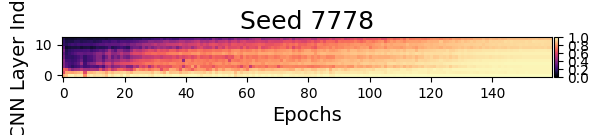

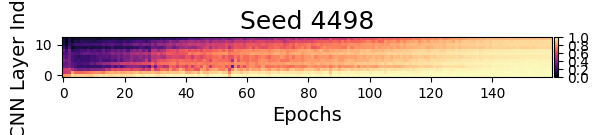

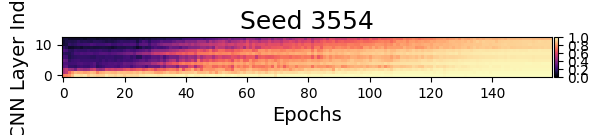

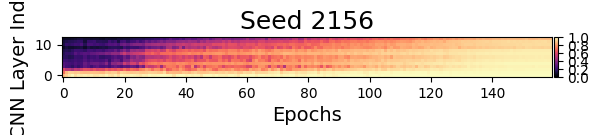

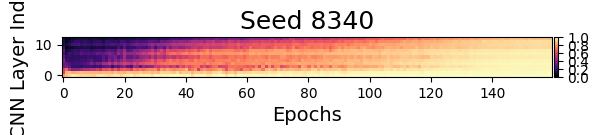

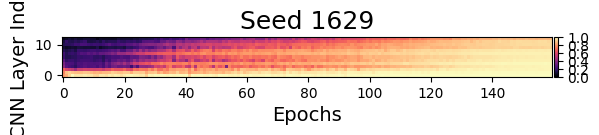

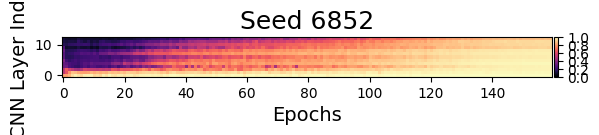

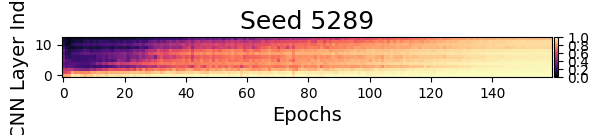

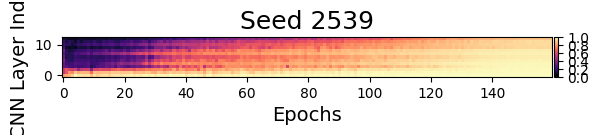

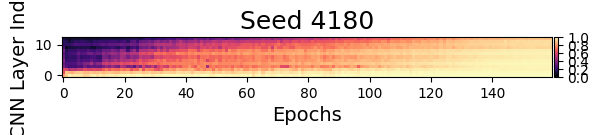

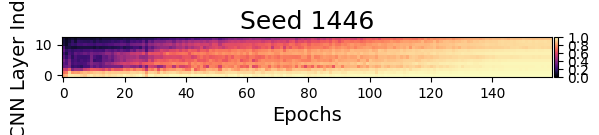

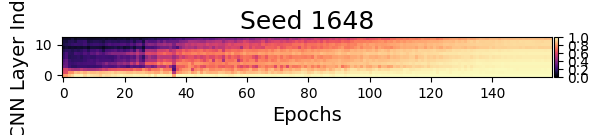

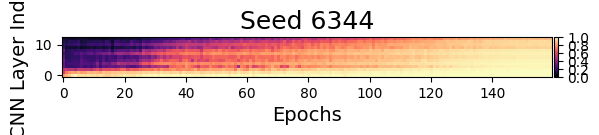

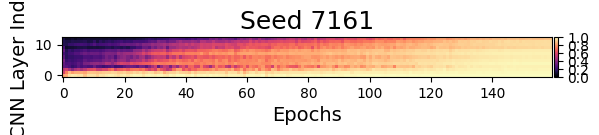

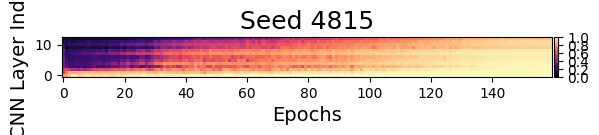

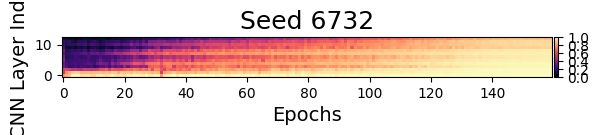

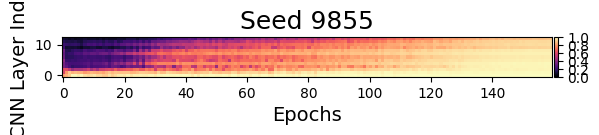

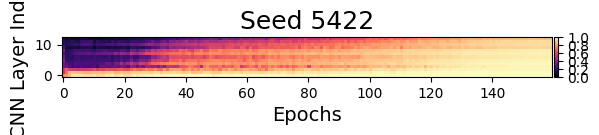

In [12]:
for seed_directory in seed_directories:
    path_to_cka = os.path.join(name_of_experiment, seed_directory, "cka_values_across_epochs.pkl")
    match = re.search(r"(\d+)$", seed_directory)
    if match:
        seed = int(match.group(1))
    plot_cka_over_time(path_to_cka, seed)

## 3) Compare Metrics of 2 Arbitrarily Chosen Seeds
* Allows you to measure how different the full training across different seeds were

In [13]:
def plot_accuracy_of_full_vs_similarity_guided_training_metrics(full_training_file, similarity_guided_training_file):
    with open(full_training_file, 'rb') as f:
        full_training = pickle.load(f)
    with open(similarity_guided_training_file, 'rb') as f:
        similarity_guided_training = pickle.load(f)

    acc_full, train_loss_full, test_loss_full = full_training
    acc_sim, train_loss_sim, test_loss_sim = similarity_guided_training

    epochs = list(range(1, len(acc_full) + 1))

    for index, (acc1, acc2) in enumerate(zip(acc_full, acc_sim)):
        acc_full[index] = acc1 * 100.0
        acc_sim[index] = acc2 * 100.0
    print(f"Max Accuracy Full Training: {max(acc_full)}")
    print(f"Max Accuracy Similarity-Guided Training: {max(acc_sim)}")
    # Plot Accuracy
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, acc_full, label='End-to-End Accuracy')
    plt.plot(epochs, acc_sim, label='Similarity-Guided Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_loss_full, label='End-to-End Training Loss')
    plt.plot(epochs, train_loss_sim, label='Similarity-Guided Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Validation Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_loss_full, label='End-to-End Validation Loss')
    plt.plot(epochs, train_loss_sim, label='Similarity-Guided Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

Max Accuracy Full Training: 76.99000000000001
Max Accuracy Similarity-Guided Training: 76.73


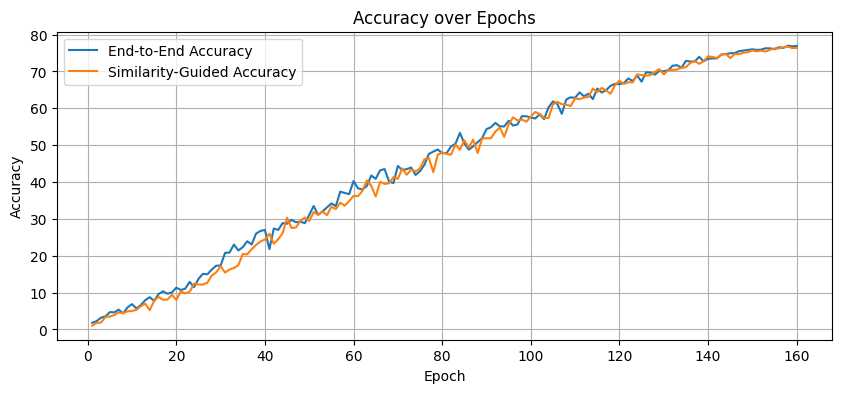

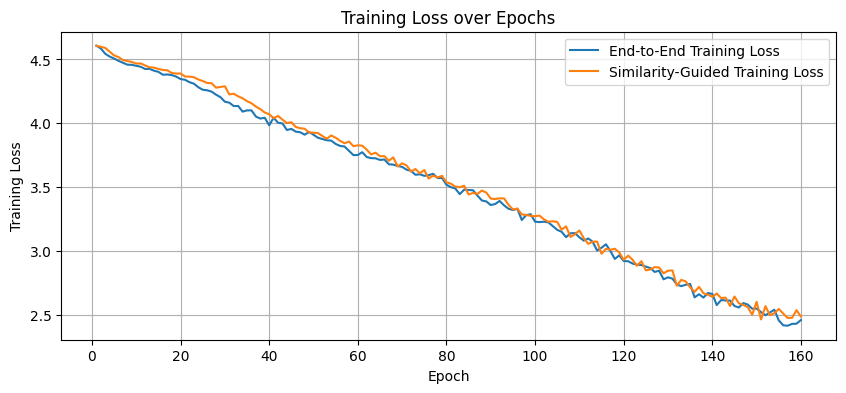

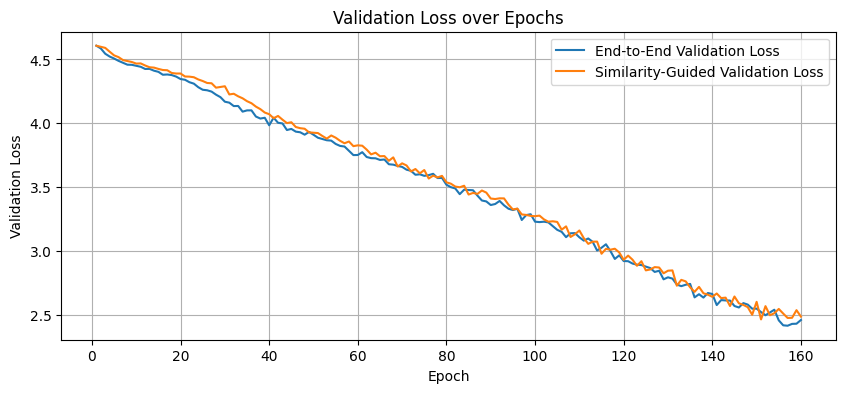

In [16]:
chosen_seeds = random.sample(seed_directories, 2)
first_seed_exp = os.path.join(name_of_experiment, chosen_seeds[0], "fully_trained_reference_model_metrics.pkl")
second_seed_exp = os.path.join(name_of_experiment, chosen_seeds[1], "fully_trained_reference_model_metrics.pkl")
plot_accuracy_of_full_vs_similarity_guided_training_metrics(first_seed_exp, second_seed_exp)

## 4) Plot CKA Curves
* Used for the visualization of CKA and also determining when certain layers converge.

In [17]:
def plot_cka_over_time_results(all_epochs_matrix, number_of_conv, seed):
    # Convert PyTorch tensor to NumPy if needed
    if isinstance(all_epochs_matrix, torch.Tensor):
        all_epochs_matrix = all_epochs_matrix.cpu().numpy()

    num_rows, num_cols = all_epochs_matrix.shape
    time_steps = np.arange(num_rows)

    for i in range(number_of_conv):
        plt.title(f"Conv # {i}, Seed {seed}")
        plt.plot(time_steps, all_epochs_matrix[:, i])
    plt.show()

def compare_plots_of_cka_over_time(all_epochs_matrix_one, all_epochs_matrix_two, number_of_conv, seed_one, seed_two):
    if isinstance(all_epochs_matrix_one, torch.Tensor):
        all_epochs_matrix_one = all_epochs_matrix_one.cpu().numpy()
        all_epochs_matrix_two = all_epochs_matrix_two.cpu().numpy()
    
    num_rows, num_cols = all_epochs_matrix_one.shape
    time_steps = np.arange(num_rows)
    for i in range(number_of_conv):
        plt.title(f"Conv # {i}, Seed {seed_one} vs. Seed {seed_two}")
        plt.plot(time_steps, all_epochs_matrix_one[:, i])
        plt.plot(time_steps, all_epochs_matrix_two[:, i])
    plt.show()
    
def process_cka_over_time_file_for_plot(seed_directory):
    global name_of_experiment
    cka_over_time_file = os.path.join(name_of_experiment, seed_directory, "cka_values_across_epochs.pkl")
    with open(cka_over_time_file, "rb") as f:
        cka_over_time = pickle.load(f)
    list_of_layers = list(cka_over_time.keys())
    max_epochs = max(len(cka_over_time[key]) for key in list(cka_over_time.keys()))
    max_layers = len(list_of_layers)
    cka_matrix = torch.zeros((max_layers, max_epochs))
    for layer_index, layer in enumerate(list_of_layers):
        max_epochs_trained_for_layer = len(cka_over_time[layer])
        for epoch in range(max_epochs_trained_for_layer):
            cka_matrix[layer_index][epoch] = cka_over_time[layer][epoch]
    all_epochs_matrix = cka_matrix.T
    return all_epochs_matrix

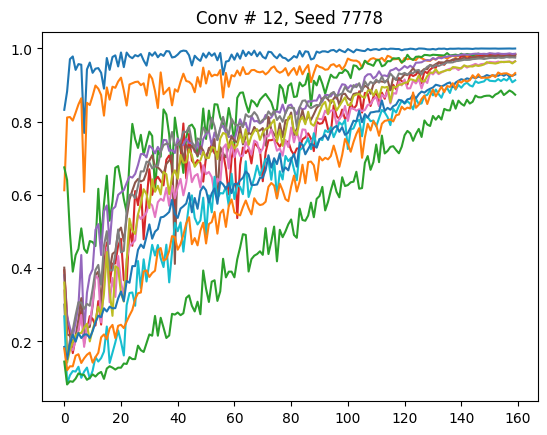

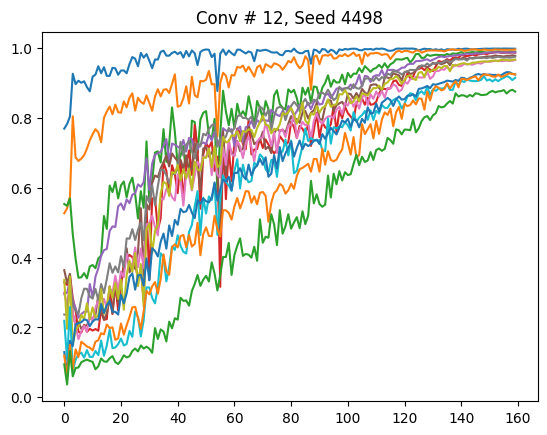

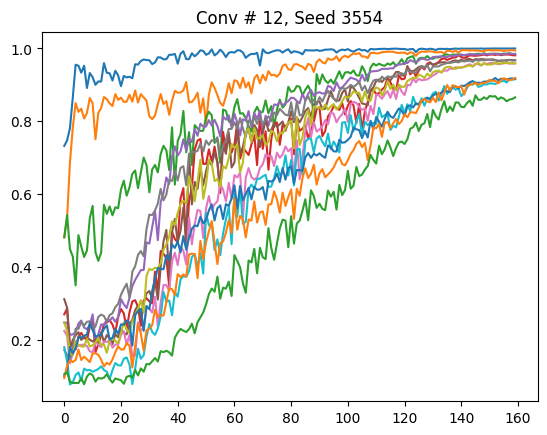

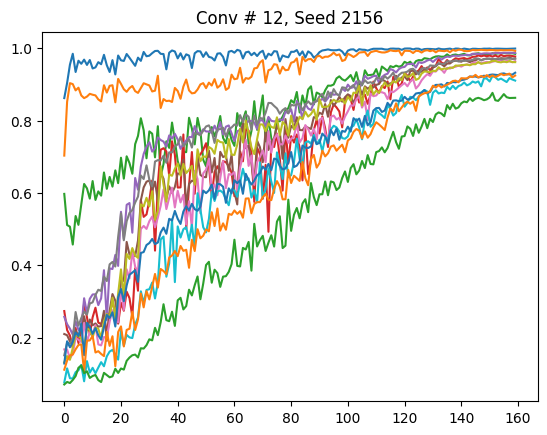

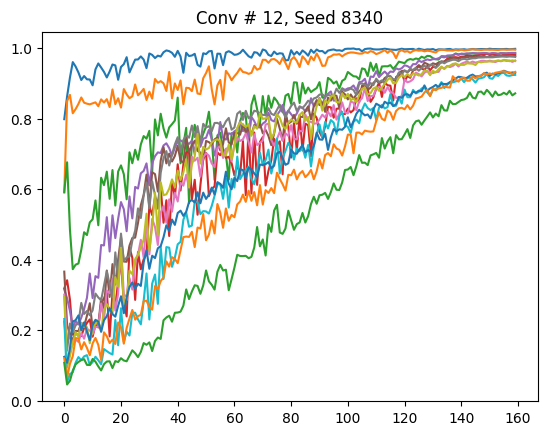

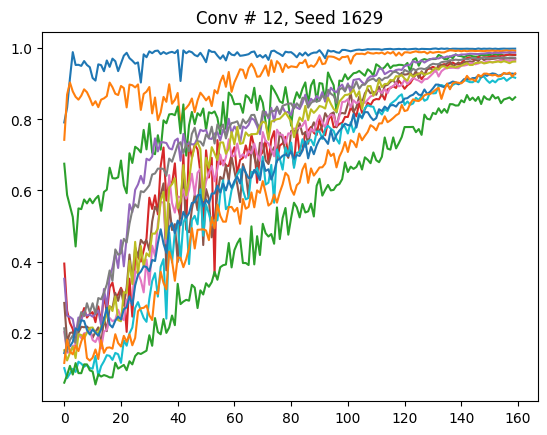

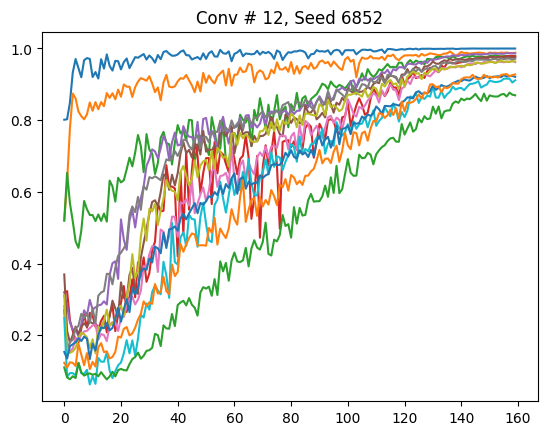

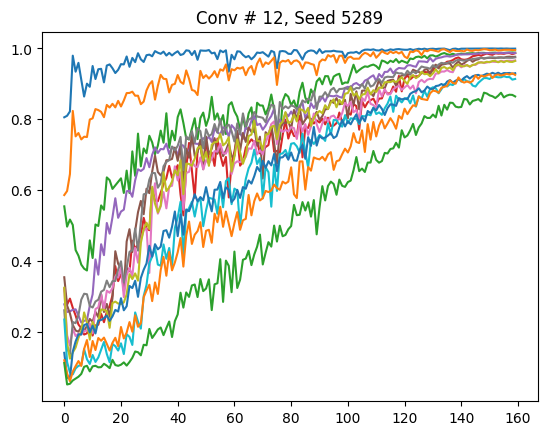

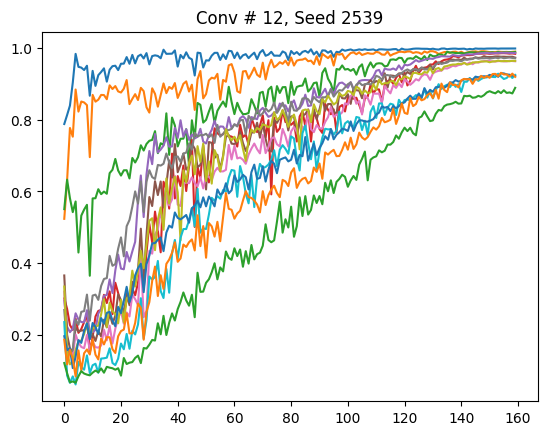

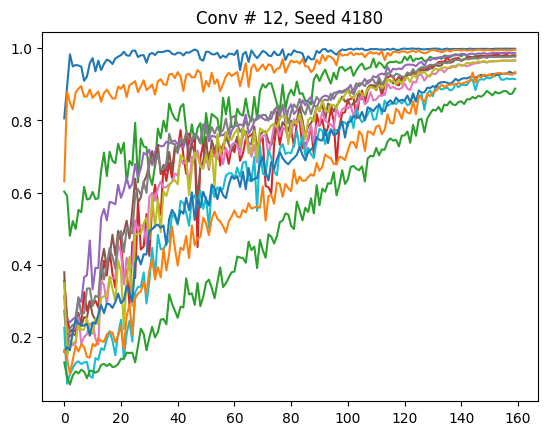

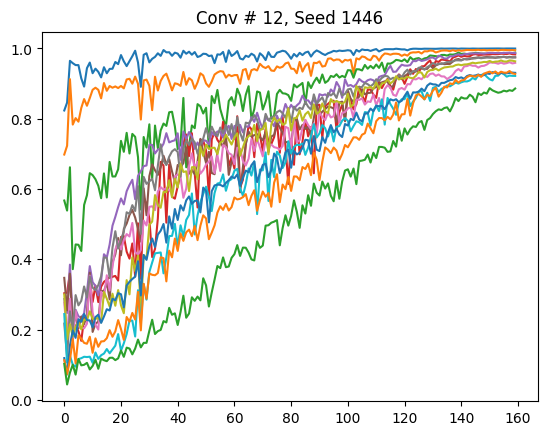

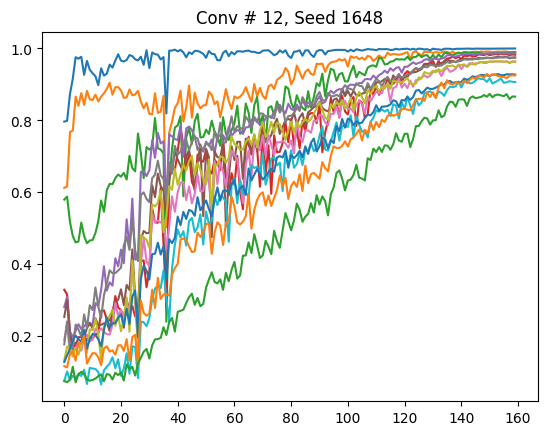

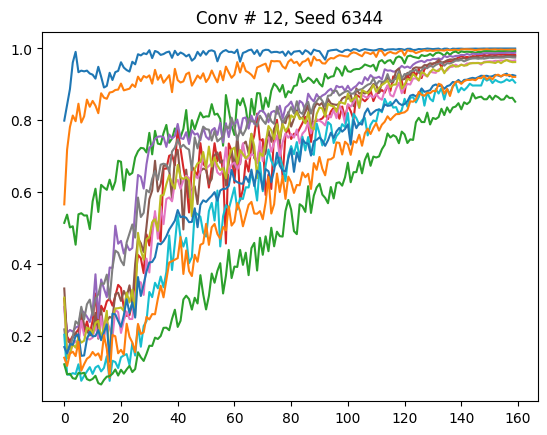

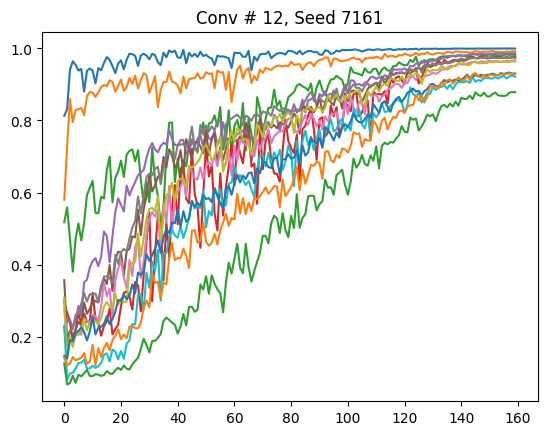

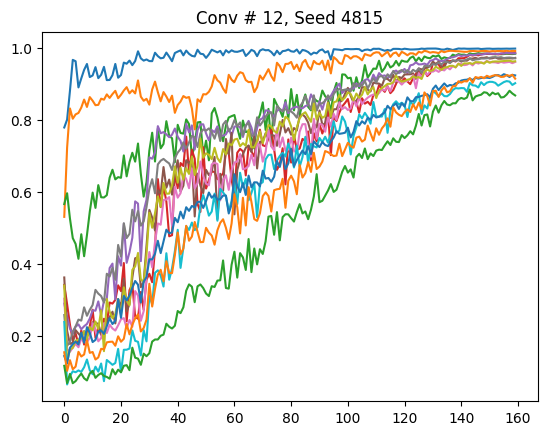

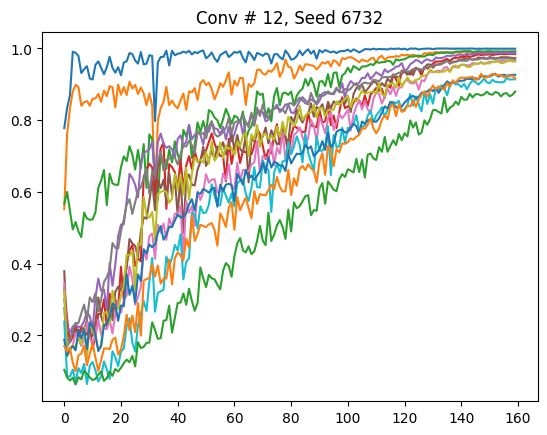

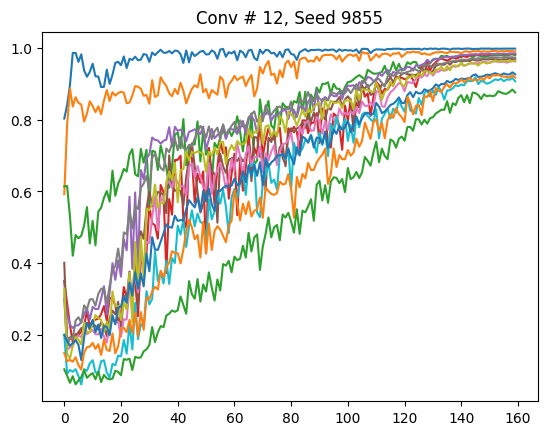

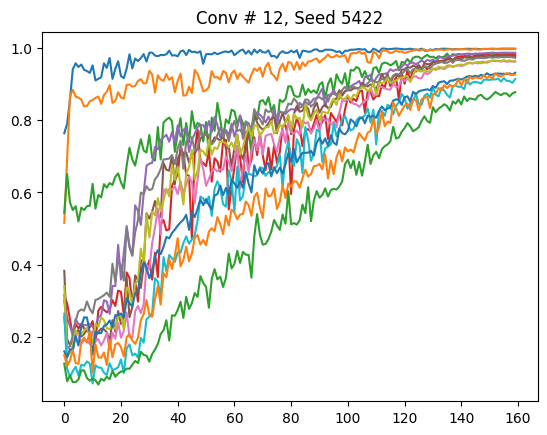

In [19]:
for seed_directory in seed_directories:
    all_epochs_matrix = process_cka_over_time_file_for_plot(seed_directory)
    match = re.search(r"(\d+)$", seed_directory)
    if match:
        seed = int(match.group(1))
    plot_cka_over_time_results(all_epochs_matrix, number_of_cnn_layers_for_cka, seed)

## 5) Produce Labels for the CKA Curves on when they Stabilize (Variance Stabilization)
* You can specify your moving window for the variance computation with **moving_window**
* You can specify your stride with **moving_window_stride**
* You can specify stability threshold with **stability_threshold**
* You can set a cutoff for when to consider a layer frozen inside the moving window, a change rate for the CKA values with **cka_change_rate_threshold_between_strides**

In [22]:
moving_window = 20
moving_window_stride = 5
stability_threshold = 0.0001
cka_change_rate_threshold_between_strides = 0.1

In [23]:
def get_all_stability_points_for_all_layers(
    all_epochs_matrix, conv_indices, layers, seed, moving_window=20, stride=5, stability_threshold=0.0002, cka_change_rate_threshold_between_strides=0.1
):
    cka_freeze_configuration = {layer: [] for layer in layers}
    num_epochs = all_epochs_matrix.shape[0]

    for conv_idx in conv_indices:
        cka_vals = all_epochs_matrix[:, conv_idx]
        if hasattr(cka_vals, 'cpu'):
            cka_vals = cka_vals.cpu().numpy()

        cka_window_values = []
        variance_values = []   # Store variance for plotting
        variance_epochs = []   # Track the center of the window for plotting

        prev_decision_was_frozen = False
        prev_CKA_at_decision_for_frozen = None

        for epoch, cka_val in enumerate(cka_vals):
            cka_window_values.append(cka_val)

            if len(cka_window_values) > moving_window:
                cka_window_values = cka_window_values[stride:]

            if len(cka_window_values) == moving_window:
                window_variance = np.var(cka_window_values, ddof=1)

                center_epoch = (epoch - moving_window + 1) // 2
                start_of_epoch = epoch - moving_window + 1
                # print(f"The Current Epoch: {epoch}, Start of Epoch: {epoch} - {moving_window} = {start_of_epoch}")
                variance_values.append(window_variance)
                variance_epochs.append(center_epoch)
                # After the initial freeze decision, make it so that all labels subsequently are of a frozen layer
                # Doesn't make sense to go back and forth with freezing, measure performance difference after. Weights should change slightly anyway
                if window_variance < stability_threshold and cka_val > 0.3 or cka_freeze_configuration[layers[conv_idx]][-1] == 1:
                    # print(f"Layer {conv_idx} — CKA value when freezing: ", cka_val)
                    # print("Variance of window: ", window_variance)
                    cka_freeze_configuration[layers[conv_idx]].append(1) # 1 for frozen layer
                    cka_freeze_configuration[layers[conv_idx]][-moving_window:] = [1] * moving_window # replace last moving_window elements with 1 for frz
                    prev_decision_was_frozen = True
                    prev_CKA_at_decision_for_frozen = cka_val
                else:
                  cka_freeze_configuration[layers[conv_idx]].append(0) # 0 for non-frozen layer
                  prev_decision_was_frozen = False
                  prev_CKA_at_decision_for_frozen = None
            else:
              if prev_decision_was_frozen:
                # Get percent change, has to be a less than 3% change from the CKA value that was previously frozen at
                prev_cka_value_pct_change = abs(prev_CKA_at_decision_for_frozen - cka_val) / prev_CKA_at_decision_for_frozen
                if prev_cka_value_pct_change < cka_change_rate_threshold_between_strides:
                  cka_freeze_configuration[layers[conv_idx]].append(1) # following previous decision of layer freezing
                else:
                  print(f"GREATER THAN {int(cka_change_rate_threshold_between_strides * 100.0)} CHANGE IN CKA VALUE, NOT CHOSEN AS A FROZEN LAYER")
                  cka_freeze_configuration[layers[conv_idx]].append(0)
              else:
                cka_freeze_configuration[layers[conv_idx]].append(0) # following previous decision of layer freezing, or there haven't been enough epochs for test

        # Plotting
        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.plot(cka_vals, label='Raw CKA', color='blue', alpha=0.3)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('CKA Similarity', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.set_ylim(0, 1.0)

        # Plot variance on secondary axis
        ax2 = ax1.twinx()
        ax2.plot(variance_epochs, variance_values, label='Variance', color='orange')
        ax2.set_ylabel('Window Variance', color='orange')
        ax2.set_ylim(0.0001, 0.001)
        ax2.tick_params(axis='y', labelcolor='orange')

        # Plot the first stability marker if found
        frz_moment = [epoch_index for epoch_index, frz_decision in enumerate(cka_freeze_configuration[layers[conv_idx]]) if frz_decision == 1]
        cka_val_at_frz_moment = [cka_vals[epoch_index] for epoch_index in frz_moment]
        if frz_moment is not None:
            ax1.plot(frz_moment, cka_val_at_frz_moment, 'ro', label=f'Stability Point (<{stability_threshold})')

        fig.suptitle(f'Seed {seed}, CKA and Variance — Conv {layers[conv_idx]}')
        fig.tight_layout()
        fig.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    return cka_freeze_configuration

In [ ]:
cka_frz_layer_configurations = {}
for seed_directory in seed_directories:
    match = re.search(r"(\d+)$", seed_directory)
    if match:
        seed = int(match.group(1))
    all_epochs_matrix = process_cka_over_time_file_for_plot(seed_directory)
    cka_configuration = get_all_stability_points_for_all_layers(all_epochs_matrix, 
                                                                seed=seed, 
                                                                conv_indices=[i for i in range(number_of_cnn_layers_for_cka)], 
                                                                layers=layer_names, 
                                                                moving_window=moving_window,
                                                               stride=moving_window_stride,
                                                               stability_threshold=stability_threshold,
                                                               cka_change_rate_threshold_between_strides=cka_change_rate_threshold_between_strides)
    cka_frz_layer_configurations[seed] = cka_configuration

## 6) Count Number of Frozen vs. Non-Frozen Samples Generated for this Freezing Dataset
* Also gives seed specific splits on frozen vs. non-frozen samples, in addition the totals at the end

In [26]:
number_of_frozen_samples = 0
number_of_non_frozen_samples = 0
for seed_num, frz_predictions in cka_frz_layer_configurations.items():
    seed_frz_epochs = 0
    seed_no_frz_epochs = 0
    for layer_name in layer_names:
        layer_frz_predictions = frz_predictions[layer_name]
        seed_frz_epochs += sum([pred == 1 for pred in layer_frz_predictions])
        seed_no_frz_epochs += sum([pred == 0 for pred in layer_frz_predictions])
    number_of_frozen_samples += seed_frz_epochs
    number_of_non_frozen_samples += seed_no_frz_epochs
    print(f"Seed {seed_num}, #of Frz Samples: {seed_frz_epochs}, #of NoFrz Samples: {seed_no_frz_epochs}")
print(f"Total number of Frozen Samples: {number_of_frozen_samples}, Total number of Non-Frozen Samples: {number_of_non_frozen_samples}")

Seed 7778, #of Frz Samples: 535, #of NoFrz Samples: 1545
Seed 4498, #of Frz Samples: 495, #of NoFrz Samples: 1585
Seed 3554, #of Frz Samples: 510, #of NoFrz Samples: 1570
Seed 2156, #of Frz Samples: 490, #of NoFrz Samples: 1590
Seed 8340, #of Frz Samples: 480, #of NoFrz Samples: 1600
Seed 1629, #of Frz Samples: 490, #of NoFrz Samples: 1590
Seed 6852, #of Frz Samples: 500, #of NoFrz Samples: 1580
Seed 5289, #of Frz Samples: 510, #of NoFrz Samples: 1570
Seed 2539, #of Frz Samples: 495, #of NoFrz Samples: 1585
Seed 4180, #of Frz Samples: 465, #of NoFrz Samples: 1615
Seed 1446, #of Frz Samples: 475, #of NoFrz Samples: 1605
Seed 1648, #of Frz Samples: 520, #of NoFrz Samples: 1560
Seed 6344, #of Frz Samples: 545, #of NoFrz Samples: 1535
Seed 7161, #of Frz Samples: 505, #of NoFrz Samples: 1575
Seed 4815, #of Frz Samples: 515, #of NoFrz Samples: 1565
Seed 6732, #of Frz Samples: 540, #of NoFrz Samples: 1540
Seed 9855, #of Frz Samples: 495, #of NoFrz Samples: 1585
Seed 5422, #of Frz Samples: 520

## 7) Generate the training data for the SmartFRZ predictor
* Start generating the folder for that dataset

In [35]:
log_each_sample_for_printing = False
indices_for_sampling = list(range(context_window_size))
    
output_dir_for_freezing = f"{location_for_training_data}/context_window_{context_window_size}"
os.makedirs(output_dir_for_freezing, exist_ok=True)
os.makedirs(os.path.join(output_dir_for_freezing, "frz"), exist_ok=True)
os.makedirs(os.path.join(output_dir_for_freezing, "nofrz"), exist_ok=True)

# Iterate through each seed creating data
for seed_num, frz_predictions in cka_frz_layer_configurations.items():
    # Iterate through each epoch
    for epoch in range(num_epochs):
        input_file = f"{name_of_experiment}/smartfrz_input_data/seed_{seed_num}_*/epoch_{epoch}.pkl"
        found_input_files = glob.glob(input_file)
        if len(found_input_files) != 1:
            raise ValueError(f"Failed to get the unique input file for epoch {epoch} and seed {seed_num}")
        with open(found_input_files[0], "rb") as f:
            layer_input_weights = pickle.load(f)

        for layer_name in layer_names:
            layer_frz_pred = frz_predictions[layer_name][epoch]
            
            if log_each_sample_for_printing:
                print(f'Frz Pred for {layer_name}, Seed {seed_num}, (Epoch, Pred): ({epoch}, {layer_frz_pred})')

            input_weights = [layer_input_weights[layer_name][i] for i in indices_for_sampling]

            if layer_frz_pred == 0:
                # Non-frozen layer
                with open(os.path.join(output_dir_for_freezing, "nofrz", f"layer_{layer_name}_epoch_{epoch}_{seed_num}.pkl"), "wb") as f:
                    pickle.dump(input_weights, f)
            else:
                # Frozen layer
                with open(os.path.join(output_dir_for_freezing, "frz", f"layer_{layer_name}_epoch_{epoch}_{seed_num}.pkl"), "wb") as f:
                    pickle.dump(input_weights, f)